# 03 — Explainability Analysis (XAI)

**Purpose:** Generate clinically interpretable figures for the report and presentation.
The goal is not deployment explainability — it is to identify which signal features
the model relies on most, and whether those align with known physiology of pharyngeal
airflow obstruction. Findings will be shared with a domain expert for clinical validation.

## Framing
- *Does the model learn what a clinician would expect it to learn?*
- *Where the model struggles, does the signal pattern have a physiological explanation?*
- Results here are **hypotheses** to be validated, not ground truth.

## Sections

| Section | Content | Figure |
|---------|---------|--------|
| 2 | LogReg coefficients — linear feature weights | `logreg_coef_report.png` |
| 3 | Global SHAP (LightGBM) — mean importance + beeswarm | `shap_global_report.png` |
| 4 | SHAP by physiological group | `shap_by_group_report.png` |
| 5 | Feature group ablation — which groups drive AUC? | `ablation_report.png` |
| 6 | LogReg contribution per breath — per-breath explainability | `breath_contributions_report.png` |
| 7 | Error analysis — FN vs FP SHAP signatures | `shap_error_report.png` |
| 8 | Low-AUC patient analysis | `shap_outlier_report.png` |
| 9 | Domain expert summary table | printed |

## Inputs
- `features_clean_v2.csv` — 11-feature dataset from notebook 01-1
- `models/model_lightgbm_v2.pkl` — LightGBM on full data (for SHAP)
- `models/model_logreg_v2.pkl` + `models/scaler_logreg_v2.pkl` — LogReg baseline
- `models/lopo_cv_results_v2.csv` — per-patient LOPO metrics from notebook 02

## Note on SHAP on full-data model
SHAP is computed on the full-data LightGBM model applied to all data.
This is appropriate for understanding *what the model learned* globally,
but is not a valid estimate of held-out prediction quality — that comes from LOPO-CV.

## 1. Setup & Load

In [1]:
import warnings
import joblib
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import shap
import lightgbm as lgb

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, confusion_matrix

warnings.filterwarnings('ignore')
shap.initjs()

# ── Report-ready plot style ───────────────────────────────────────────────────
mpl.rcParams.update({
    'figure.facecolor' : 'white',
    'axes.facecolor'   : 'white',
    'axes.edgecolor'   : 'black',
    'axes.labelcolor'  : 'black',
    'xtick.color'      : 'black',
    'ytick.color'      : 'black',
    'text.color'       : 'black',
    'font.size'        : 11,
    'axes.titlesize'   : 12,
    'axes.labelsize'   : 11,
    'legend.fontsize'  : 10,
    'figure.dpi'       : 150,
})

# ── Paths ─────────────────────────────────────────────────────────────────────
MODEL_DIR    = Path('./models')
FEATURES_CSV = Path('features_clean_v2.csv')
LOPO_CSV     = MODEL_DIR / 'lopo_cv_results_v2.csv'
FIG_DIR      = Path('./figures')
FIG_DIR.mkdir(exist_ok=True)

# ── Feature set (must match notebooks 01-1 & 02) ─────────────────────────────
FEATURE_NAMES = [
    'quad_insp_50', 'area_under_peaks_insp',
    'power_5to12_insp', 'power_5to12_exp',
    'flatness_insp_90',
    'insp_peak_position',
    'insp_duty', 'breath_duration',
    'exp_cv', 'insp_skew', 'insp_kurt',
]

# ── Physiological groups (Mann et al. categories) ────────────────────────────
# Used for group-level SHAP and ablation.
# Localisable = can highlight a region of the breath waveform.
# Non-localisable = whole-phase statistic or spectral — no waveform region.
FEATURE_GROUPS = {
    'Scooping'          : ['quad_insp_50', 'area_under_peaks_insp'],
    'Flutter (spectral)': ['power_5to12_insp', 'power_5to12_exp'],
    'Flatness'          : ['flatness_insp_90'],
    'Asymmetry'         : ['insp_peak_position'],
    'Phase timing'      : ['insp_duty', 'breath_duration'],
    'Shape variability' : ['exp_cv', 'insp_skew', 'insp_kurt'],
}
NON_LOCALISABLE_GROUPS = {'Flutter (spectral)', 'Shape variability'}

GROUP_COLORS = {
    'Scooping'          : '#c0392b',
    'Flutter (spectral)': '#2980b9',
    'Flatness'          : '#e67e22',
    'Asymmetry'         : '#27ae60',
    'Phase timing'      : '#8e44ad',
    'Shape variability' : '#7f8c8d',
}

# ── Load data ─────────────────────────────────────────────────────────────────
df       = pd.read_csv(FEATURES_CSV)
df       = df[df['target'].isin([0, 1])].dropna(subset=FEATURE_NAMES).reset_index(drop=True)
X        = df[FEATURE_NAMES].values
y        = df['target'].values
lopo_df  = pd.read_csv(LOPO_CSV)

# ── Load models ───────────────────────────────────────────────────────────────
lgbm_model = joblib.load(MODEL_DIR / 'model_lightgbm_v2.pkl')
lr_model   = joblib.load(MODEL_DIR / 'model_logreg_v2.pkl')
scaler_lr  = joblib.load(MODEL_DIR / 'scaler_logreg_v2.pkl')

print(f'Dataset   : {len(df)} breaths, {df["participant"].nunique()} patients')
print(f'FL        : {(y==1).sum()}  |  NFL: {(y==0).sum()}')
print(f'Features  : {len(FEATURE_NAMES)}')
print(f'Models loaded: LightGBM, LogReg')

Dataset   : 6993 breaths, 84 patients
FL        : 3627  |  NFL: 3366
Features  : 11
Models loaded: LightGBM, LogReg


## 2. LogReg Coefficients

The most transparent explainability view available: each coefficient directly states
how much a one-SD increase in that feature pushes the log-odds toward FL.
Because features are StandardScaler'd before fitting, coefficients are comparable
in magnitude across features.

LogReg coefficients (scaled, positive = pushes toward FL):
              feature              group  coefficient direction
            insp_kurt  Shape variability     0.739543      → FL
            insp_skew  Shape variability     0.574614      → FL
      power_5to12_exp Flutter (spectral)     0.496658      → FL
     power_5to12_insp Flutter (spectral)     0.489019      → FL
               exp_cv  Shape variability    -0.479484     → NFL
      breath_duration       Phase timing     0.368362      → FL
area_under_peaks_insp           Scooping     0.312833      → FL
            insp_duty       Phase timing     0.177620      → FL
         quad_insp_50           Scooping     0.125017      → FL
     flatness_insp_90           Flatness    -0.110809     → NFL
   insp_peak_position          Asymmetry    -0.093057     → NFL


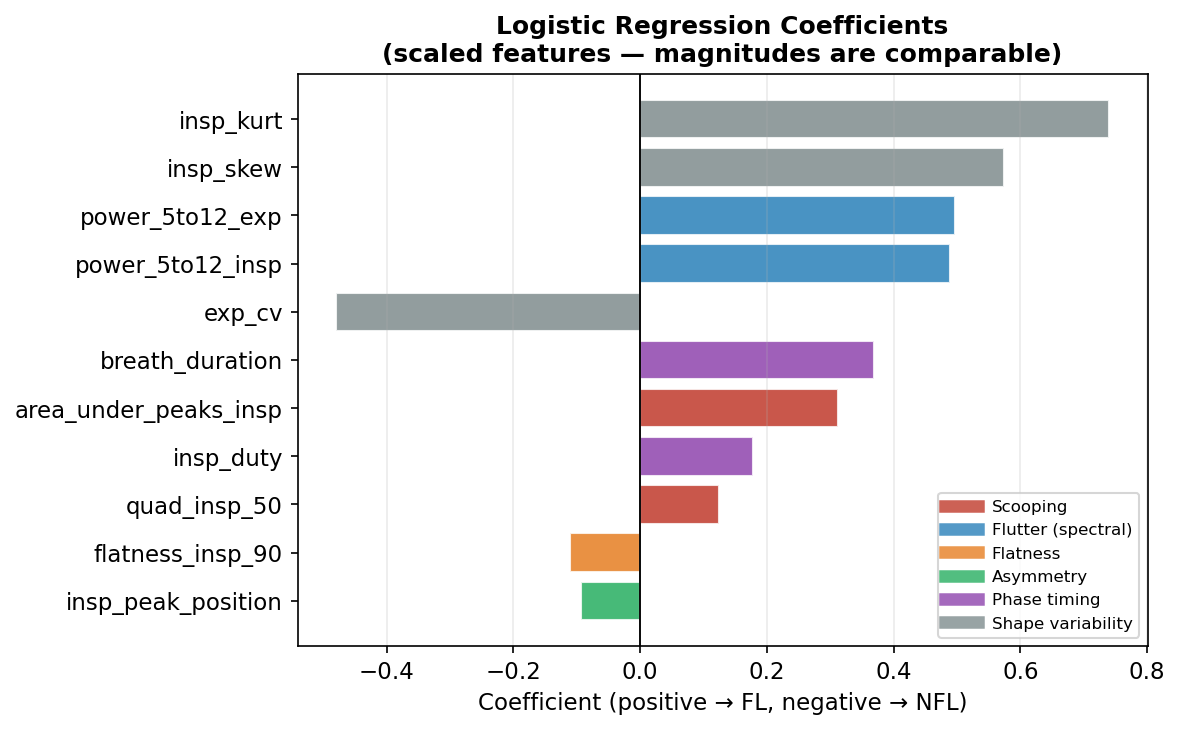

Saved: logreg_coef_report.png

--- DOMAIN EXPERT VALIDATION QUESTIONS ---
Top positive contributors (toward FL):
  insp_kurt                      coef=+0.740  [Shape variability]
  insp_skew                      coef=+0.575  [Shape variability]
  power_5to12_exp                coef=+0.497  [Flutter (spectral)]
  power_5to12_insp               coef=+0.489  [Flutter (spectral)]
  breath_duration                coef=+0.368  [Phase timing]

Top negative contributors (toward NFL):
  exp_cv                         coef=-0.479  [Shape variability]
  flatness_insp_90               coef=-0.111  [Flatness]
  insp_peak_position             coef=-0.093  [Asymmetry]

→ Ask domain expert: does this direction of influence match clinical expectation?


In [2]:
coef_df = pd.DataFrame({
    'feature'    : FEATURE_NAMES,
    'coefficient': lr_model.coef_[0],
}).sort_values('coefficient', key=abs, ascending=False)

coef_df['group'] = coef_df['feature'].apply(
    lambda f: next((g for g, fs in FEATURE_GROUPS.items() if f in fs), 'Other')
)
coef_df['direction'] = coef_df['coefficient'].apply(lambda v: '→ FL' if v > 0 else '→ NFL')

print('LogReg coefficients (scaled, positive = pushes toward FL):')
print(coef_df[['feature','group','coefficient','direction']].to_string(index=False))

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
colors  = [GROUP_COLORS.get(g, '#aaa') for g in coef_df['group']]
bars    = ax.barh(coef_df['feature'], coef_df['coefficient'],
                  color=colors, alpha=0.85, edgecolor='white')
ax.axvline(0, color='black', lw=0.9)
ax.set_xlabel('Coefficient (positive → FL, negative → NFL)')
ax.set_title('Logistic Regression Coefficients\n'
             '(scaled features — magnitudes are comparable)',
             fontweight='bold')
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.25)

# Group legend
for grp, col in GROUP_COLORS.items():
    ax.plot([], [], color=col, lw=6, alpha=0.8, label=grp)
ax.legend(fontsize=8, loc='lower right')

plt.tight_layout()
plt.savefig(FIG_DIR / 'logreg_coef_report.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: logreg_coef_report.png')

print('\n--- DOMAIN EXPERT VALIDATION QUESTIONS ---')
print('Top positive contributors (toward FL):')
for _, r in coef_df[coef_df['coefficient'] > 0].head(5).iterrows():
    print(f'  {r["feature"]:<30} coef={r["coefficient"]:+.3f}  [{r["group"]}]')
print('\nTop negative contributors (toward NFL):')
for _, r in coef_df[coef_df['coefficient'] < 0].head(3).iterrows():
    print(f'  {r["feature"]:<30} coef={r["coefficient"]:+.3f}  [{r["group"]}]')
print('\n→ Ask domain expert: does this direction of influence match clinical expectation?')

## 3. Global SHAP — LightGBM Feature Importance

SHAP TreeExplainer gives exact values (no sampling approximation) for LightGBM.
Computed on full dataset — valid for understanding *what the model learned*,
not for evaluating individual held-out predictions.

The beeswarm shows both importance (x-axis position) and direction of effect
(high feature value = red, low = blue). This is the key figure for the domain expert.

In [3]:
print('Computing SHAP values (TreeExplainer on LightGBM)...')
explainer   = shap.TreeExplainer(lgbm_model)
shap_values = explainer.shap_values(X)

# LightGBM binary returns list [neg_class, pos_class] or single array
if isinstance(shap_values, list):
    shap_fl = shap_values[1]
else:
    shap_fl = shap_values

shap_df       = pd.DataFrame(shap_fl, columns=FEATURE_NAMES)
mean_abs_shap = shap_df.abs().mean().sort_values(ascending=False)

print(f'SHAP computed: {shap_fl.shape}')
print('\nMean |SHAP| per feature:')
for feat, val in mean_abs_shap.items():
    grp = next((g for g, fs in FEATURE_GROUPS.items() if feat in fs), 'Other')
    loc = '⬛ non-localisable' if grp in NON_LOCALISABLE_GROUPS else '📍 localisable'
    print(f'  {feat:<30} {val:.4f}   [{grp}] {loc}')

Computing SHAP values (TreeExplainer on LightGBM)...
SHAP computed: (6993, 11)

Mean |SHAP| per feature:
  power_5to12_exp                0.5005   [Flutter (spectral)] ⬛ non-localisable
  power_5to12_insp               0.4791   [Flutter (spectral)] ⬛ non-localisable
  insp_kurt                      0.3850   [Shape variability] ⬛ non-localisable
  insp_peak_position             0.2908   [Asymmetry] 📍 localisable
  insp_duty                      0.2761   [Phase timing] 📍 localisable
  breath_duration                0.2741   [Phase timing] 📍 localisable
  exp_cv                         0.2652   [Shape variability] ⬛ non-localisable
  insp_skew                      0.2516   [Shape variability] ⬛ non-localisable
  area_under_peaks_insp          0.2210   [Scooping] 📍 localisable
  flatness_insp_90               0.2151   [Flatness] 📍 localisable
  quad_insp_50                   0.1116   [Scooping] 📍 localisable


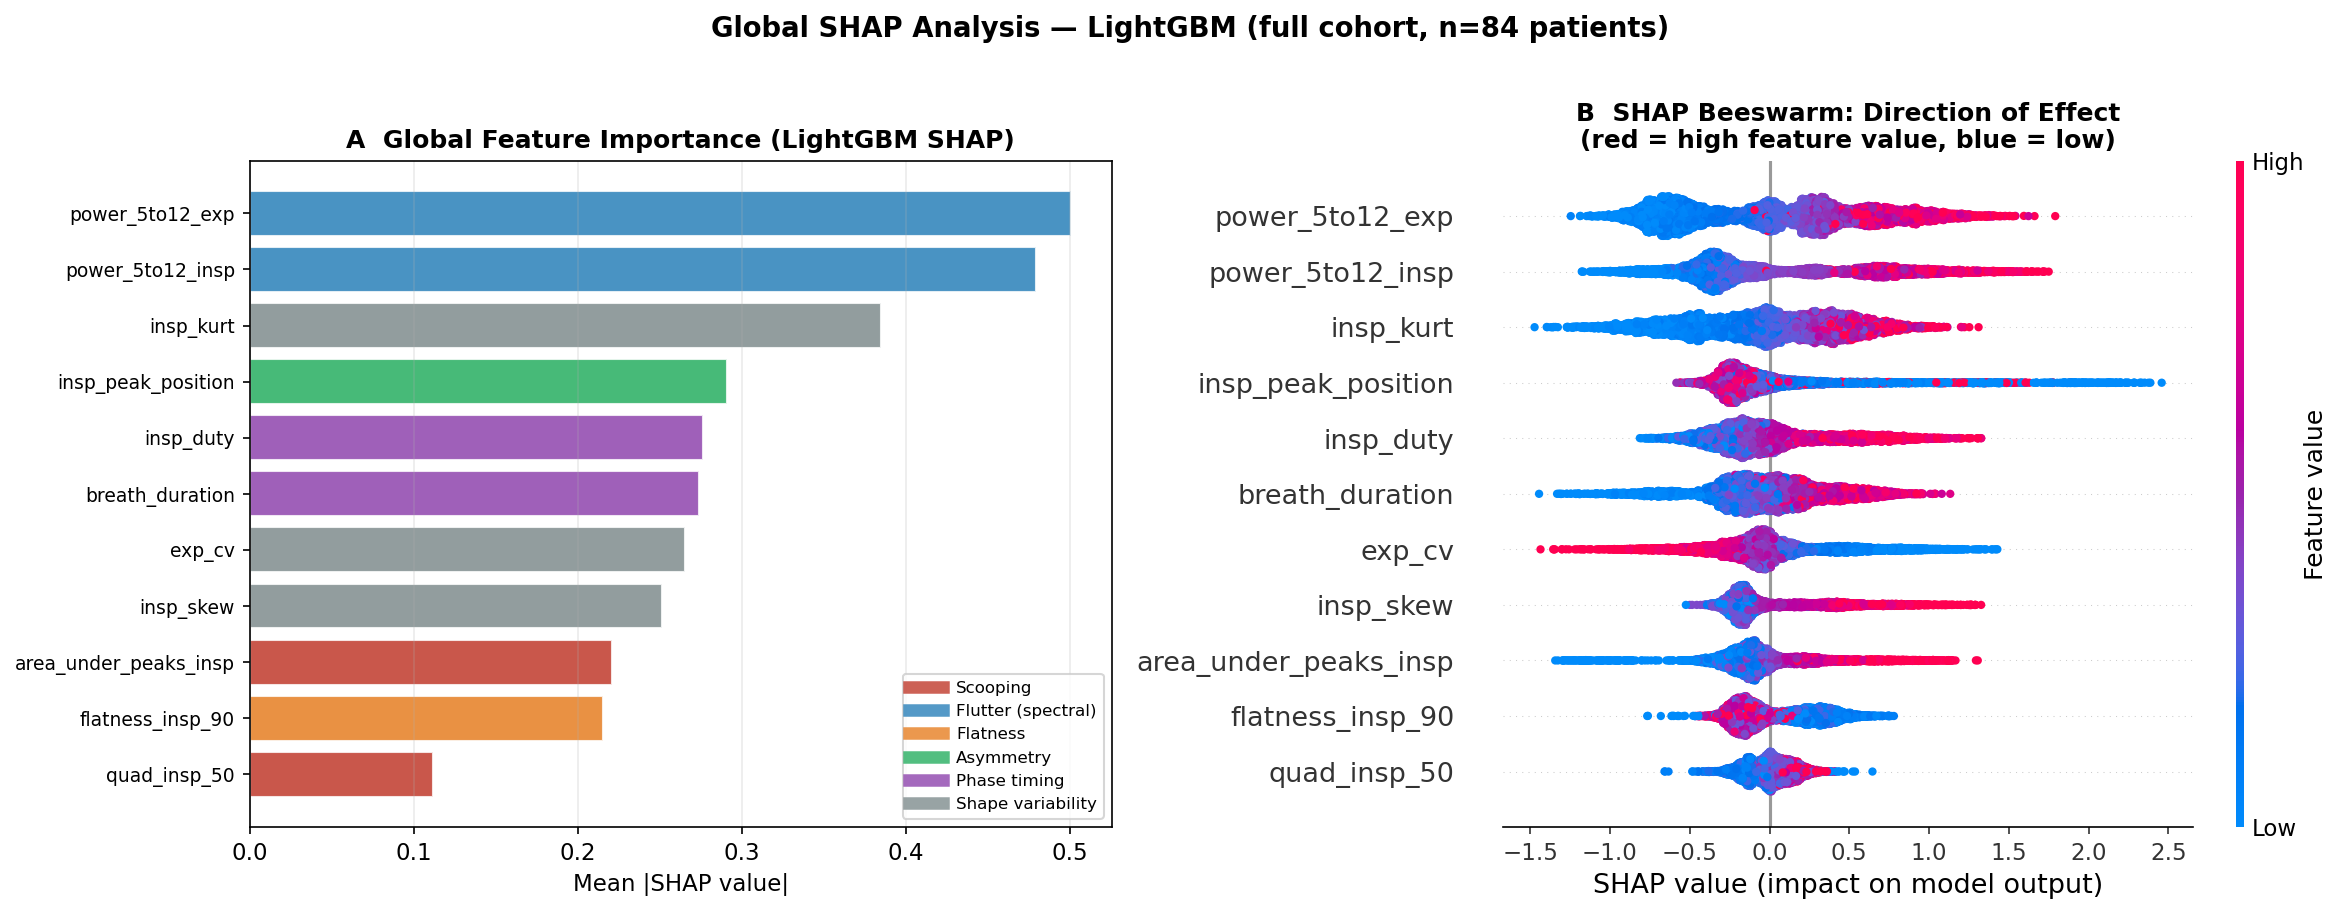

Saved: shap_global_report.png

--- DOMAIN EXPERT VALIDATION QUESTIONS ---
From the beeswarm, confirm direction of effect for each feature:
  High insp_kurt, insp_skew  → FL? (heavy-tailed / skewed inspiration = obstructed?)
  High power_5to12_insp/exp  → FL? (more flutter = more obstruction?)
  Low flatness_insp_90       → FL? (less plateau = more rounded = obstructed?)
  High area_under_peaks_insp → FL? (more scooping = more obstruction?)


In [4]:
# ── Figure: mean |SHAP| bar + beeswarm ───────────────────────────────────────
feat_order = mean_abs_shap.index.tolist()
bar_cols   = [GROUP_COLORS.get(
    next((g for g, fs in FEATURE_GROUPS.items() if f in fs), ''), '#aaa'
) for f in feat_order]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: mean |SHAP| bar
ax = axes[0]
bars = ax.barh(range(len(feat_order)), mean_abs_shap[feat_order].values,
               color=bar_cols, alpha=0.85, edgecolor='white')
ax.set_yticks(range(len(feat_order)))
ax.set_yticklabels(feat_order, fontsize=9)
ax.invert_yaxis()
ax.set_xlabel('Mean |SHAP value|')
ax.set_title('A  Global Feature Importance (LightGBM SHAP)', fontweight='bold')
ax.grid(axis='x', alpha=0.25)
for grp, col in GROUP_COLORS.items():
    ax.plot([], [], color=col, lw=6, alpha=0.8, label=grp)
ax.legend(fontsize=8, loc='lower right')

# Right: beeswarm
plt.sca(axes[1])
shap.summary_plot(
    shap_fl, X,
    feature_names=FEATURE_NAMES,
    plot_type='dot',
    show=False,
    plot_size=None,
    max_display=len(FEATURE_NAMES),
)
axes[1].set_title('B  SHAP Beeswarm: Direction of Effect\n'
                  '(red = high feature value, blue = low)',
                  fontweight='bold')

plt.suptitle('Global SHAP Analysis — LightGBM (full cohort, n=84 patients)',
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR / 'shap_global_report.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: shap_global_report.png')

print('\n--- DOMAIN EXPERT VALIDATION QUESTIONS ---')
print('From the beeswarm, confirm direction of effect for each feature:')
print('  High insp_kurt, insp_skew  → FL? (heavy-tailed / skewed inspiration = obstructed?)')
print('  High power_5to12_insp/exp  → FL? (more flutter = more obstruction?)')
print('  Low flatness_insp_90       → FL? (less plateau = more rounded = obstructed?)')
print('  High area_under_peaks_insp → FL? (more scooping = more obstruction?)')

## 4. SHAP by Physiological Group

Aggregate SHAP contributions by Mann et al. feature category.
Answers: *which physiological mechanism is the model most relying on?*
This is the most directly clinically interpretable view.

=== Mean |SHAP| by physiological group ===
  Flutter (spectral)        0.48981  [NON-LOCALISABLE]
  Shape variability         0.30060  [NON-LOCALISABLE]
  Asymmetry                 0.29077  [localisable]  
  Phase timing              0.27507  [localisable]  
  Flatness                  0.21515  [localisable]  
  Scooping                  0.16630  [localisable]  


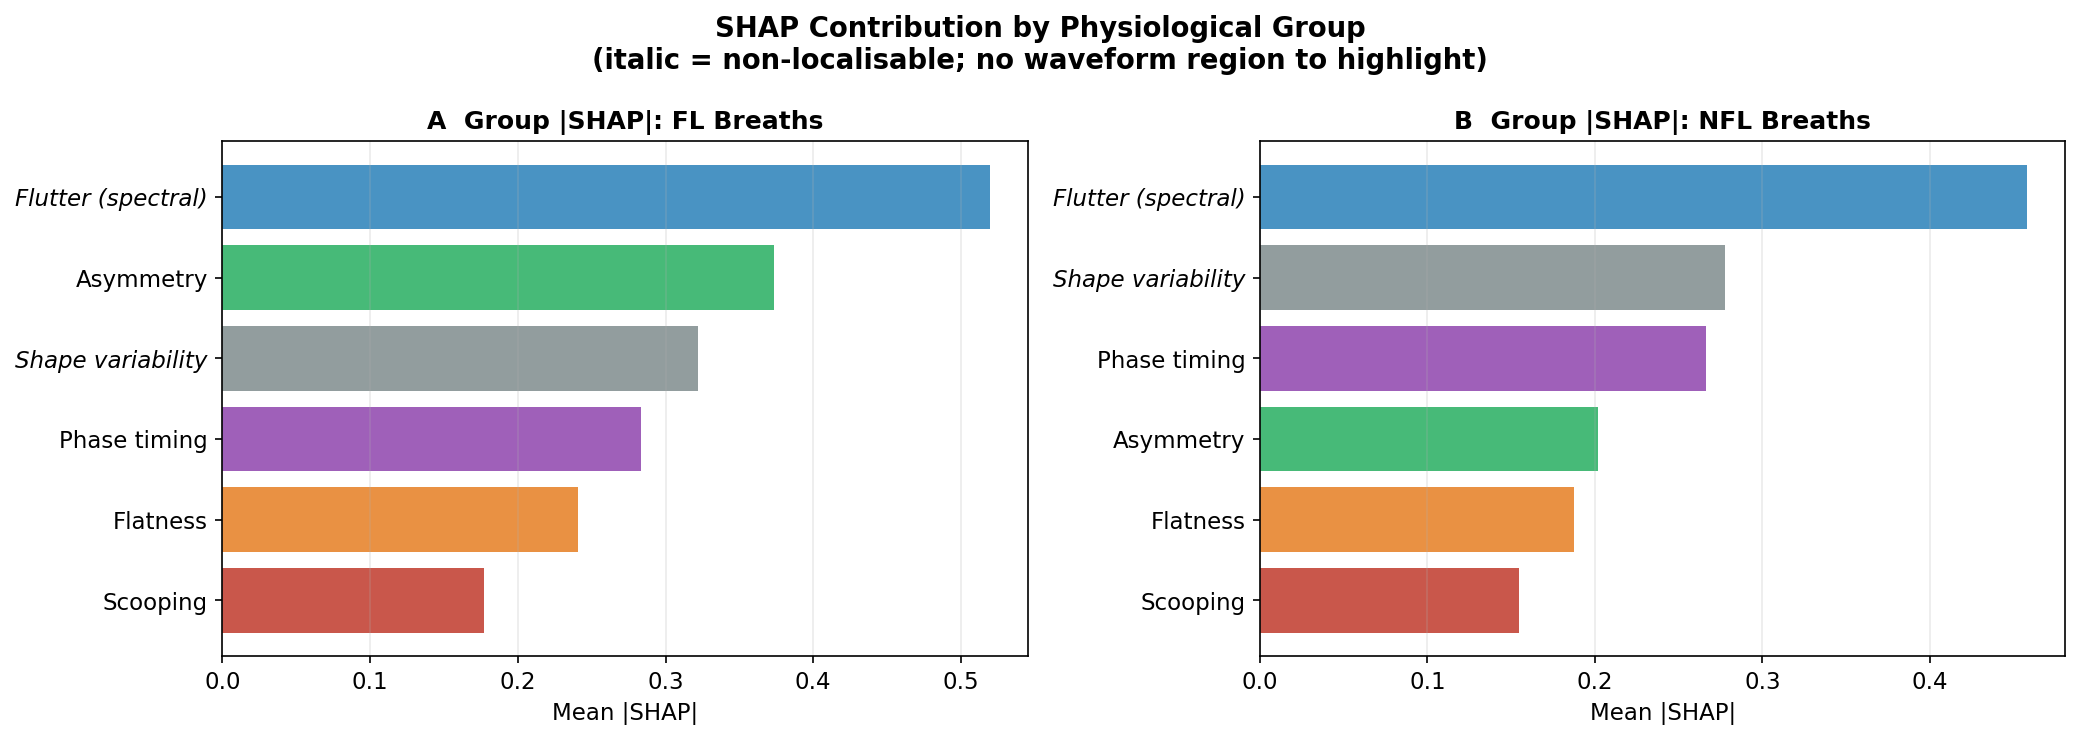

Saved: shap_by_group_report.png

--- DOMAIN EXPERT VALIDATION QUESTIONS ---
Does the relative group ranking match clinical intuition?
E.g., is Shape variability being weighted appropriately vs Scooping?
Are there groups that should matter more based on clinical experience?


In [5]:
# ── Per-group mean |SHAP| ─────────────────────────────────────────────────────
group_shap = {}
for grp, feats in FEATURE_GROUPS.items():
    valid = [f for f in feats if f in FEATURE_NAMES]
    group_shap[grp] = float(shap_df[valid].abs().values.mean())

group_shap_s = pd.Series(group_shap).sort_values(ascending=False)

print('=== Mean |SHAP| by physiological group ===')
for grp, val in group_shap_s.items():
    loc = '[NON-LOCALISABLE]' if grp in NON_LOCALISABLE_GROUPS else '[localisable]  '
    print(f'  {grp:<25} {val:.5f}  {loc}')

# ── FL vs NFL separately ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, mask, title in [
    (axes[0], y == 1, 'A  Group |SHAP|: FL Breaths'),
    (axes[1], y == 0, 'B  Group |SHAP|: NFL Breaths'),
]:
    sub      = shap_df[mask]
    grp_vals = {grp: sub[[f for f in fs if f in FEATURE_NAMES]].abs().values.mean()
                for grp, fs in FEATURE_GROUPS.items()}
    grp_s    = pd.Series(grp_vals).sort_values(ascending=True)
    colors   = [GROUP_COLORS.get(g, '#aaa') for g in grp_s.index]
    ax.barh(grp_s.index, grp_s.values, color=colors, alpha=0.85)
    ax.set_xlabel('Mean |SHAP|')
    ax.set_title(title, fontweight='bold')
    ax.grid(axis='x', alpha=0.25)
    # Mark non-localisable
    for tick, grp in zip(ax.get_yticklabels(), grp_s.index):
        if grp in NON_LOCALISABLE_GROUPS:
            tick.set_style('italic')

plt.suptitle('SHAP Contribution by Physiological Group\n'
             '(italic = non-localisable; no waveform region to highlight)',
             fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'shap_by_group_report.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: shap_by_group_report.png')

print('\n--- DOMAIN EXPERT VALIDATION QUESTIONS ---')
print('Does the relative group ranking match clinical intuition?')
print('E.g., is Shape variability being weighted appropriately vs Scooping?')
print('Are there groups that should matter more based on clinical experience?')

## 5. Feature Group Ablation

Remove one physiological group at a time and measure the drop in pooled LOPO-CV ROC-AUC.
Answers: *which feature category is the model actually relying on for performance?*

Note: this re-runs LOPO-CV per ablation — takes ~5 minutes.

In [6]:
def lopo_auc_subset(df, feature_subset):
    """LOPO-CV returning only pooled ROC-AUC for a feature subset."""
    participants = df['participant'].unique()
    trues, probas = [], []
    for test_pid in participants:
        tr = df[df['participant'] != test_pid]
        te = df[df['participant'] == test_pid]
        m  = lgb.LGBMClassifier(
            n_estimators=200, max_depth=5, learning_rate=0.05,
            num_leaves=31, subsample=0.8, colsample_bytree=0.8,
            class_weight='balanced', random_state=42, verbose=-1,
        )
        m.fit(tr[feature_subset].values, tr['target'].values)
        probas.extend(m.predict_proba(te[feature_subset].values)[:, 1].tolist())
        trues.extend(te['target'].tolist())
    return roc_auc_score(trues, probas)


# Baseline: full feature set
baseline_auc = lopo_auc_subset(df, FEATURE_NAMES)
print(f'Baseline AUC (all 11 features): {baseline_auc:.4f}\n')
print('Running ablation (one group removed at a time)...')

ablation_results = []
for grp, feats in FEATURE_GROUPS.items():
    remaining = [f for f in FEATURE_NAMES if f not in feats]
    if len(remaining) < 3:
        print(f'  Skipping {grp} — too few remaining features')
        continue
    auc_ablated = lopo_auc_subset(df, remaining)
    drop = baseline_auc - auc_ablated
    ablation_results.append({
        'group'      : grp,
        'n_removed'  : len(feats),
        'auc_ablated': auc_ablated,
        'auc_drop'   : drop,
        'localisable': grp not in NON_LOCALISABLE_GROUPS,
    })
    loc = '' if grp not in NON_LOCALISABLE_GROUPS else ' [non-localisable]'
    print(f'  {grp:<25} AUC={auc_ablated:.4f}  drop={drop:+.4f}{loc}')

ablation_df = pd.DataFrame(ablation_results).sort_values('auc_drop', ascending=False)
ablation_df.to_csv(FIG_DIR / 'ablation_results_v2.csv', index=False)
print('\nSaved: ablation_results_v2.csv')

Baseline AUC (all 11 features): 0.8441

Running ablation (one group removed at a time)...
  Scooping                  AUC=0.8450  drop=-0.0009
  Flutter (spectral)        AUC=0.8280  drop=+0.0160 [non-localisable]
  Flatness                  AUC=0.8428  drop=+0.0013
  Asymmetry                 AUC=0.8390  drop=+0.0051
  Phase timing              AUC=0.8363  drop=+0.0077
  Shape variability         AUC=0.8310  drop=+0.0130 [non-localisable]

Saved: ablation_results_v2.csv


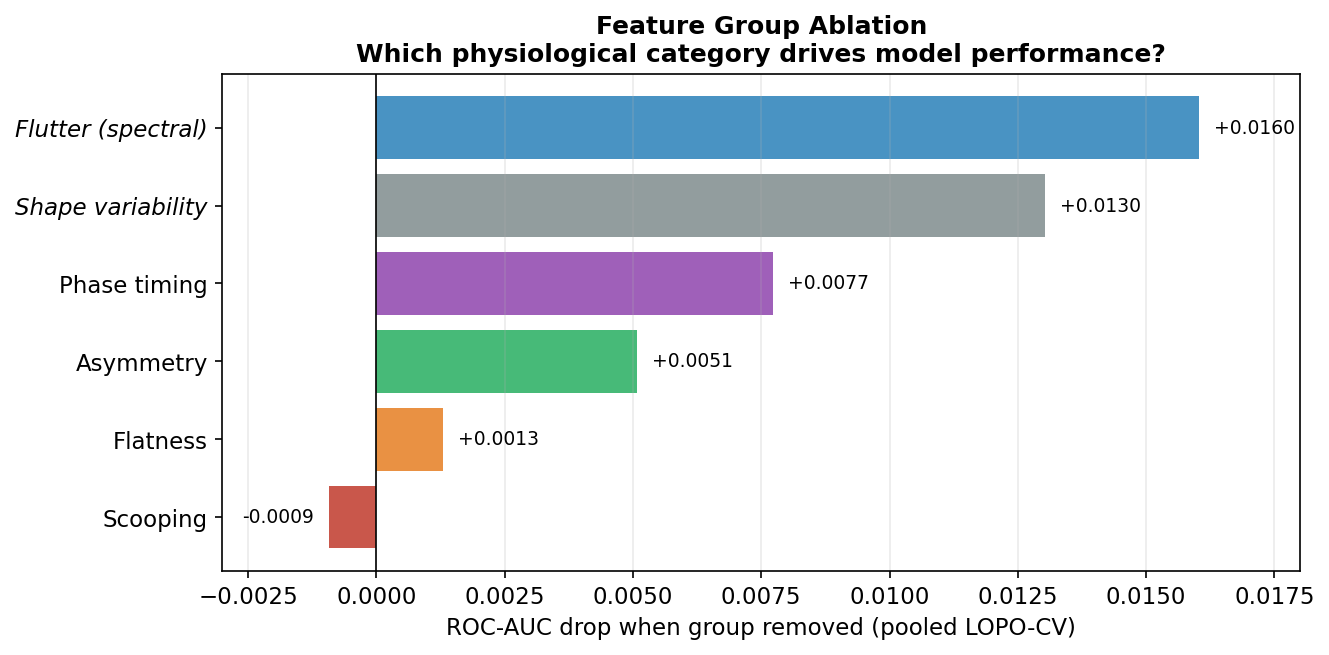

Saved: ablation_report.png

--- DOMAIN EXPERT VALIDATION QUESTIONS ---
Does the ablation ranking match the expected clinical importance of each group?
If Flutter (spectral) drops AUC strongly: does flutter frequency have known clinical significance?
If Shape variability matters more than Scooping: does that make physiological sense?


In [17]:
# ── Ablation plot ─────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4.5))
bar_colors = [GROUP_COLORS.get(g, '#aaa') for g in ablation_df['group']]
bars = ax.barh(ablation_df['group'], ablation_df['auc_drop'],
               color=bar_colors, alpha=0.85)
ax.axvline(0, color='black', lw=0.8)
ax.set_xlabel('ROC-AUC drop when group removed (pooled LOPO-CV)')
ax.set_title('Feature Group Ablation\n'
             'Which physiological category drives model performance?',
             fontweight='bold')
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.25)
ax.set_xlim(-0.003,0.018)  # leave space for value labels

# Italicise non-localisable
for tick, grp in zip(ax.get_yticklabels(), ablation_df['group']):
    if grp in NON_LOCALISABLE_GROUPS:
        tick.set_style('italic')

# Value labels
for bar, val in zip(bars, ablation_df['auc_drop']):
    # place label on right of bar if positive
    if val > 0:
        ax.text(val + 0.0003, bar.get_y() + bar.get_height()/2,
                f'{val:+.4f}', va='center', fontsize=9, color='black')
    # place label on left of bar if negative
    elif val < 0:
        ax.text(val - 0.0003, bar.get_y() + bar.get_height()/2,
                f'{val:+.4f}', va='center', fontsize=9, color='black', ha='right')

plt.tight_layout()
plt.savefig(FIG_DIR / 'ablation_report.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: ablation_report.png')

print('\n--- DOMAIN EXPERT VALIDATION QUESTIONS ---')
print('Does the ablation ranking match the expected clinical importance of each group?')
print('If Flutter (spectral) drops AUC strongly: does flutter frequency have known clinical significance?')
print('If Shape variability matters more than Scooping: does that make physiological sense?')

## 6. Per-Breath LogReg Contributions

For LogReg, the exact per-feature contribution to a breath's classification is:
  `contribution_i = coefficient_i × scaled_feature_value_i`

This is not an approximation. The sum of all contributions + intercept = log-odds.

Here we show the distribution of contributions across all breaths, separated by
FL vs NFL. This shows which features are most discriminative breath-by-breath.

Mean per-feature contribution by class (positive = toward FL):
Feature                             FL mean     NFL mean   Difference
--------------------------------------------------------------------
  insp_kurt                         +0.1775      -0.1913      +0.3688
  insp_skew                         +0.1431      -0.1542      +0.2974
  power_5to12_exp                   +0.1700      -0.1832      +0.3532
  power_5to12_insp                  +0.1814      -0.1955      +0.3768
  exp_cv                            +0.1334      -0.1438      +0.2772
  breath_duration                   +0.0351      -0.0378      +0.0729
  area_under_peaks_insp             +0.1169      -0.1259      +0.2428
  insp_duty                         +0.0276      -0.0298      +0.0574
  quad_insp_50                      +0.0374      -0.0403      +0.0778
  flatness_insp_90                  +0.0374      -0.0403      +0.0777
  insp_peak_position                +0.0110      -0.0118      +0.0227


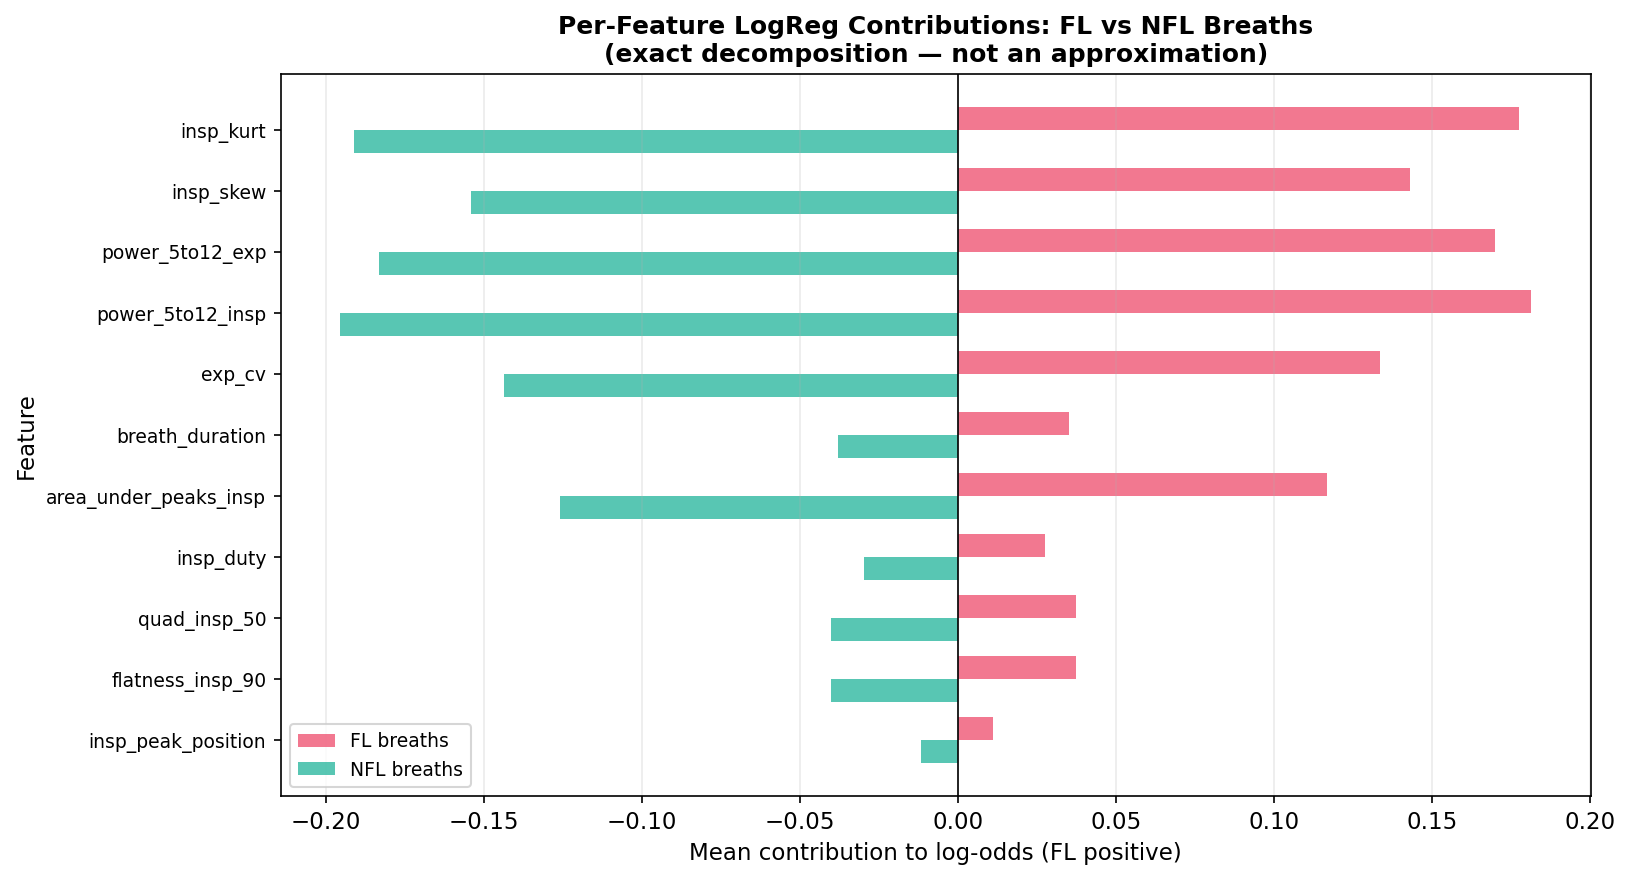

Saved: breath_contributions_report.png


In [20]:
# ── Compute per-breath contributions ─────────────────────────────────────────
X_scaled      = scaler_lr.transform(X)
contributions = X_scaled * lr_model.coef_[0]   # shape (n_breaths, n_features)
contrib_df    = pd.DataFrame(contributions, columns=FEATURE_NAMES)
contrib_df['target'] = y

fl_contrib  = contrib_df[contrib_df['target'] == 1][FEATURE_NAMES]
nfl_contrib = contrib_df[contrib_df['target'] == 0][FEATURE_NAMES]

print('Mean per-feature contribution by class (positive = toward FL):')
print(f'{"Feature":<30} {"FL mean":>12} {"NFL mean":>12} {"Difference":>12}')
print('-' * 68)
for feat in coef_df['feature']:  # sorted by |coef|
    fl_m  = fl_contrib[feat].mean()
    nfl_m = nfl_contrib[feat].mean()
    print(f'  {feat:<28} {fl_m:>+12.4f} {nfl_m:>+12.4f} {fl_m-nfl_m:>+12.4f}')

# ── Plot: horizontal mean contribution FL vs NFL ─────────────────────────────
feat_order_c = coef_df['feature'].tolist()
fl_means     = [fl_contrib[f].mean() for f in feat_order_c]
nfl_means    = [nfl_contrib[f].mean() for f in feat_order_c]

y_pos = np.arange(len(feat_order_c))
h     = 0.38

fig, ax = plt.subplots(figsize=(11, 6))
ax.barh(y_pos - h/2, fl_means,  h, label='FL breaths',  color='#ef5675', alpha=0.8)
ax.barh(y_pos + h/2, nfl_means, h, label='NFL breaths', color='#2eb8a0', alpha=0.8)
ax.axvline(0, color='black', lw=0.8)
ax.set_yticks(y_pos)
ax.set_yticklabels(feat_order_c, fontsize=9)
ax.invert_yaxis()
ax.set_xlabel('Mean contribution to log-odds (FL positive)')
ax.set_ylabel('Feature')
ax.set_title('Per-Feature LogReg Contributions: FL vs NFL Breaths\n'
             '(exact decomposition — not an approximation)',
             fontweight='bold')
ax.legend(fontsize=9)
ax.grid(axis='x', alpha=0.25)
plt.tight_layout()
plt.savefig(FIG_DIR / 'breath_contributions_report.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: breath_contributions_report.png')

## 7. Error Analysis — FN vs FP SHAP Signatures

What is the model seeing in breaths it gets wrong?
- **False Negatives (FL predicted as NFL):** missed flow limitation — clinically worse error
- **False Positives (NFL predicted as FL):** over-called

Uses LOPO held-out probabilities (rebuilt from LightGBM LOPO) at threshold=0.5.
SHAP values are from the full-data model — flagged clearly below.

In [19]:
# ── Rebuild LOPO probabilities (LightGBM) for honest error labels ─────────────
print('Rebuilding LOPO probabilities for error analysis...')
participants = df['participant'].unique()
pool_trues, pool_probas, pool_idx = [], [], []

for test_pid in participants:
    tr = df[df['participant'] != test_pid]
    te = df[df['participant'] == test_pid]
    m  = lgb.LGBMClassifier(
        n_estimators=200, max_depth=5, learning_rate=0.05,
        num_leaves=31, subsample=0.8, colsample_bytree=0.8,
        class_weight='balanced', random_state=42, verbose=-1,
    )
    m.fit(tr[FEATURE_NAMES].values, tr['target'].values)
    pool_probas.extend(m.predict_proba(te[FEATURE_NAMES].values)[:, 1].tolist())
    pool_trues.extend(te['target'].tolist())
    pool_idx.extend(te.index.tolist())

pool_trues  = np.array(pool_trues)
pool_probas = np.array(pool_probas)
pool_idx    = np.array(pool_idx)
pool_preds  = (pool_probas >= 0.5).astype(int)

fn_mask = (pool_trues == 1) & (pool_preds == 0)
fp_mask = (pool_trues == 0) & (pool_preds == 1)
tp_mask = (pool_trues == 1) & (pool_preds == 1)
tn_mask = (pool_trues == 0) & (pool_preds == 0)

print(f'At threshold=0.5 (LOPO held-out predictions):')
print(f'  TP: {tp_mask.sum()}  TN: {tn_mask.sum()}')
print(f'  FN: {fn_mask.sum()} (missed FL — clinically important)')
print(f'  FP: {fp_mask.sum()} (over-called NFL)')

Rebuilding LOPO probabilities for error analysis...
At threshold=0.5 (LOPO held-out predictions):
  TP: 2706  TN: 2648
  FN: 921 (missed FL — clinically important)
  FP: 718 (over-called NFL)


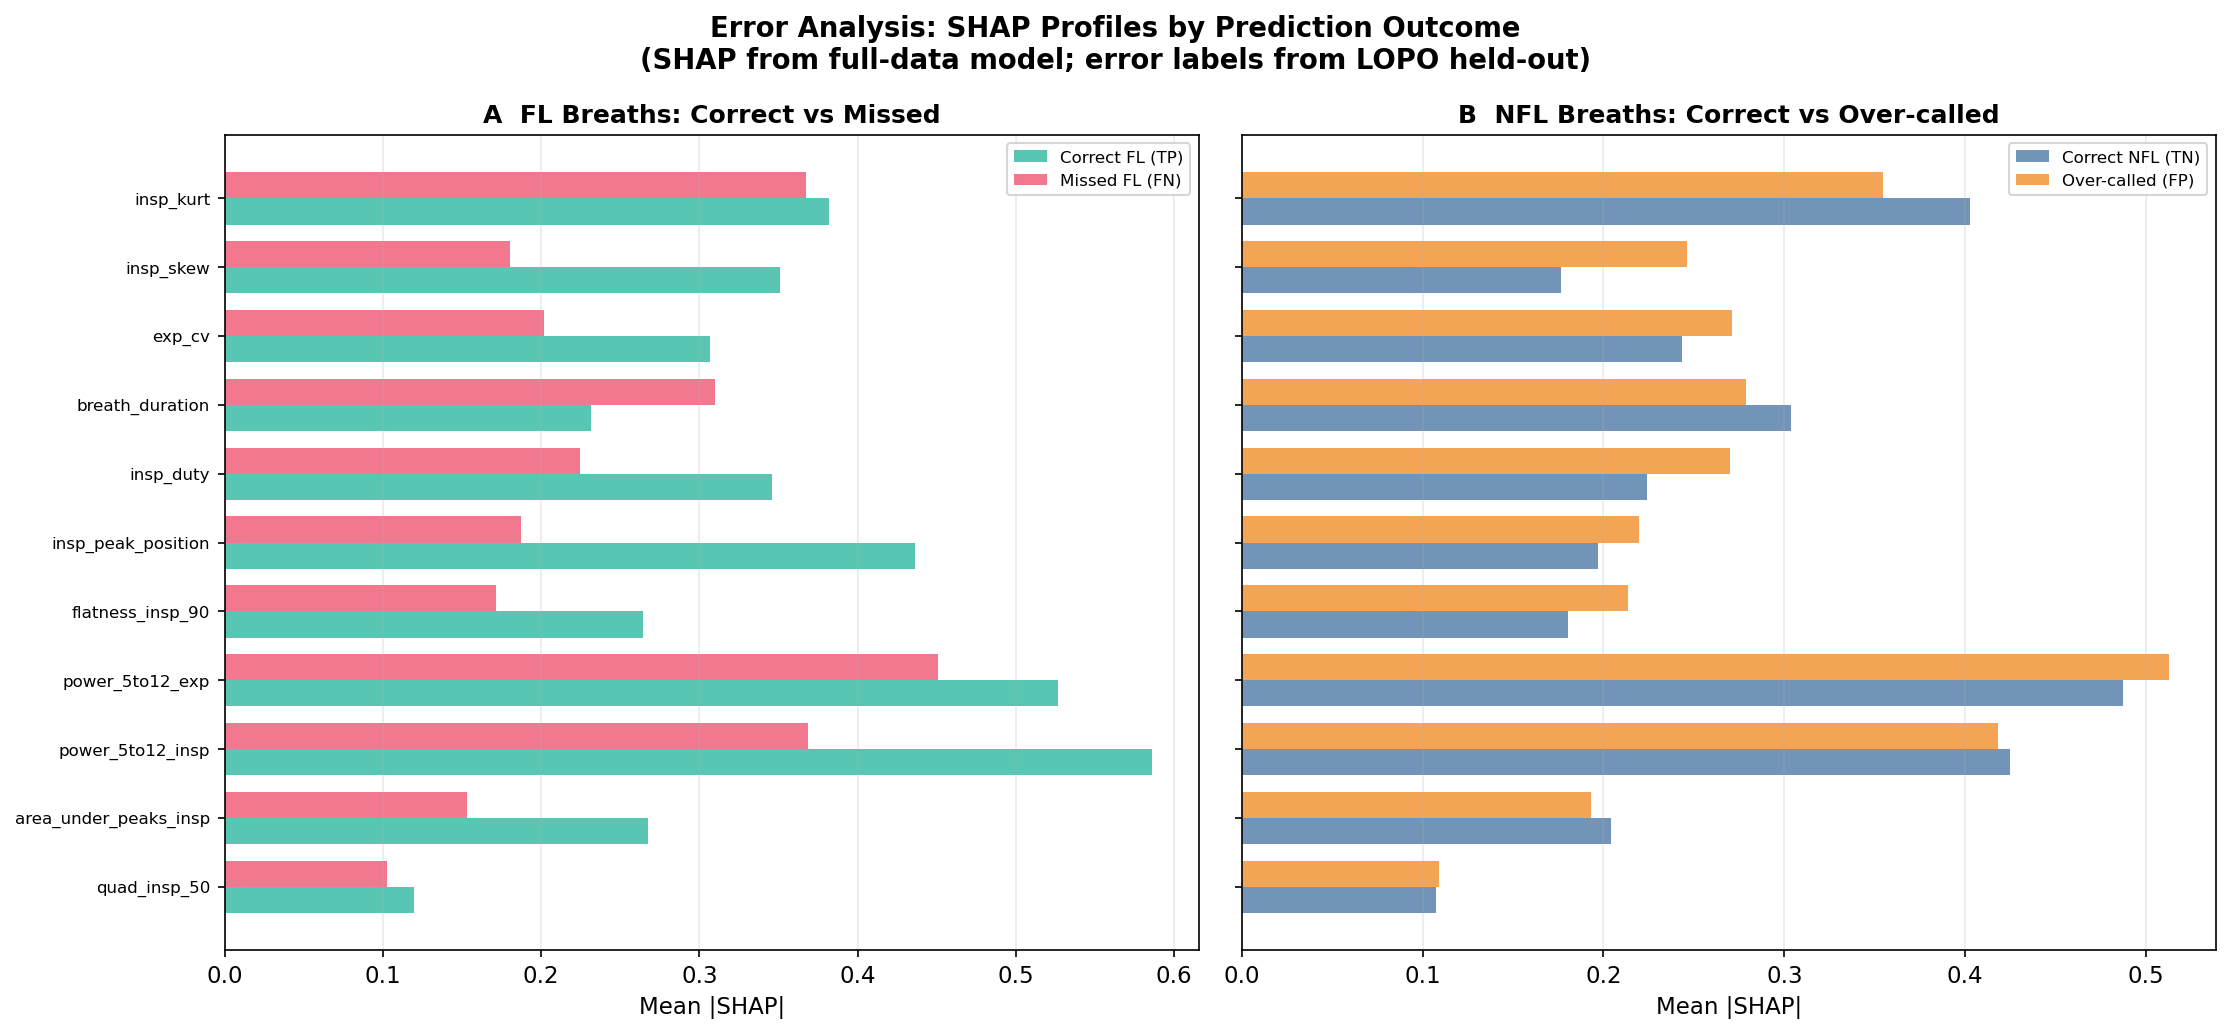

Saved: shap_error_report.png

--- DOMAIN EXPERT VALIDATION QUESTIONS ---
For missed FL breaths (FN):
  Which features are lower in FN vs TP? Does that suggest a clinical subtype?
  E.g., if flutter is low in FN: are these non-fluttering obstructed breaths?
For over-called NFL breaths (FP):
  Which features are elevated vs TN? Do these NFL breaths look obstructed?


In [22]:
# ── Mean |SHAP| profile by outcome ───────────────────────────────────────────
# SHAP from full-data model — represents learned patterns, not held-out predictions
outcome_groups = {
    'Correct FL (TP)' : pool_idx[tp_mask],
    'Missed FL (FN)'  : pool_idx[fn_mask],
    'Correct NFL (TN)': pool_idx[tn_mask],
    'Over-called (FP)': pool_idx[fp_mask],
}

profile_rows = []
for label, idx in outcome_groups.items():
    if len(idx) == 0:
        continue
    mean_shap = shap_df.iloc[idx].abs().mean()
    row = {'outcome': label}
    row.update(mean_shap.to_dict())
    profile_rows.append(row)

profile_df = pd.DataFrame(profile_rows).set_index('outcome')

# ── Plot ──────────────────────────────────────────────────────────────────────
err_colors = {
    'Correct FL (TP)' : '#2eb8a0',
    'Missed FL (FN)'  : '#ef5675',
    'Correct NFL (TN)': '#4e79a7',
    'Over-called (FP)': '#f28e2b',
}

fig, axes = plt.subplots(1, 2, figsize=(15, 7), sharey=True)

for ax, pair, title in [
    (axes[0], ['Correct FL (TP)', 'Missed FL (FN)'],    'A  FL Breaths: Correct vs Missed'),
    (axes[1], ['Correct NFL (TN)', 'Over-called (FP)'], 'B  NFL Breaths: Correct vs Over-called'),
]:
    y_pos = np.arange(len(FEATURE_NAMES))
    h     = 0.38

    for j, lbl in enumerate(pair):
        if lbl not in profile_df.index:
            continue
        vals = profile_df.loc[lbl, FEATURE_NAMES].values
        ax.barh(y_pos + (j - 0.5) * h, vals, h,
                label=lbl, color=err_colors[lbl], alpha=0.8)

    ax.set_yticks(y_pos)
    ax.set_yticklabels(FEATURE_NAMES, fontsize=8)
    ax.invert_yaxis()
    ax.set_xlabel('Mean |SHAP|')
    ax.set_title(title, fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(axis='x', alpha=0.25)

plt.suptitle('Error Analysis: SHAP Profiles by Prediction Outcome\n'
             '(SHAP from full-data model; error labels from LOPO held-out)',
             fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'shap_error_report.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: shap_error_report.png')

print('\n--- DOMAIN EXPERT VALIDATION QUESTIONS ---')
print('For missed FL breaths (FN):')
print('  Which features are lower in FN vs TP? Does that suggest a clinical subtype?')
print('  E.g., if flutter is low in FN: are these non-fluttering obstructed breaths?')
print('For over-called NFL breaths (FP):')
print('  Which features are elevated vs TN? Do these NFL breaths look obstructed?')

## 8. Low-AUC Patient Analysis

Patients where LOPO-CV AUC < 0.75 — the model consistently struggles with these.
Key question: is this a **signal quality issue** (bad data) or a **phenotype issue**
(the patient's physiology doesn't match the learned patterns)?

If their SHAP magnitudes are similar to the rest of the cohort → model is equally
confident but wrong → likely labelling noise or signal quality.

If their SHAP magnitudes are very different → different phenotype.

Low-AUC patients (LightGBM LOPO, AUC < 0.75):
   patient  n_fl  n_nfl  accuracy       f1  roc_auc    kappa
MP_2024-04    22    143  0.793939 0.320000 0.682454 0.200627
MW_2024-04    43     61  0.605769 0.438356 0.685856 0.149242
JE_2024-06    62    111  0.543353 0.563536 0.689189 0.174549
TC_2021-05    36      8  0.295455 0.243902 0.701389 0.055402
RA_2023-05    15     17  0.500000 0.600000 0.705882 0.033962
PW_2023-12    58     32  0.655556 0.659341 0.714978 0.360385
SH_2025-05    42     53  0.673684 0.673684 0.728212 0.356003
KG_2023-06    21     16  0.486486 0.173913 0.741071 0.083442
DH_2023-03    68      8  0.302632 0.361446 0.742647 0.056232

SHAP comparison: low-AUC patients (n=9) vs rest:
Feature                           Low-AUC       Rest    Ratio
--------------------------------------------------------------
  quad_insp_50                     0.1133     0.1114     1.02
  power_5to12_exp                  0.4975     0.5009     0.99
  flatness_insp_90                 0.2054    

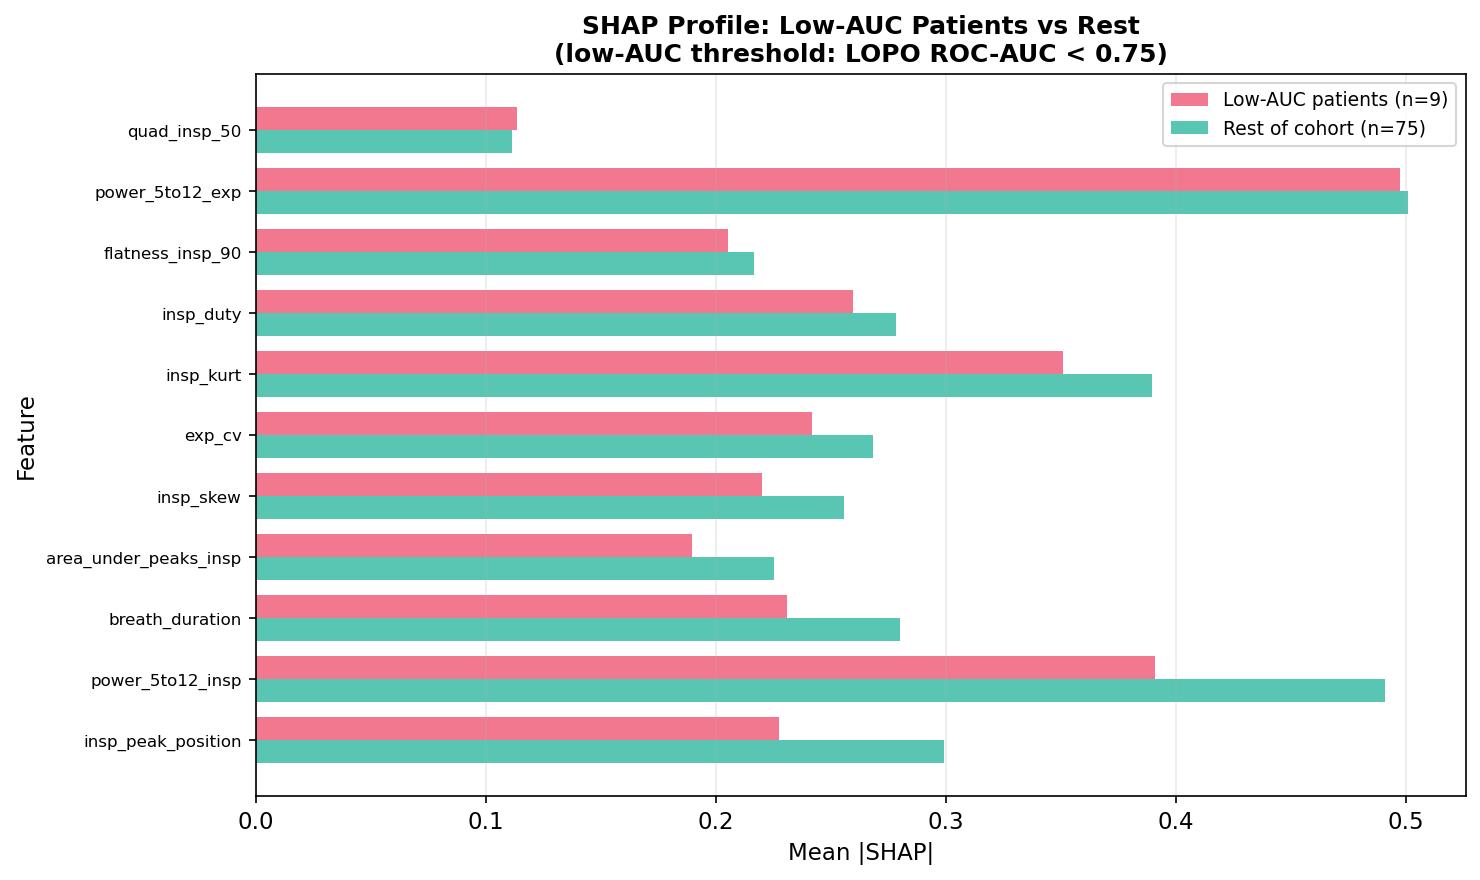

Saved: shap_outlier_report.png


In [24]:
lgbm_lopo       = lopo_df[lopo_df['model'] == 'LightGBM'].copy()
LOW_AUC_THRESH  = 0.75
low_auc_patients = lgbm_lopo[lgbm_lopo['roc_auc'] < LOW_AUC_THRESH].sort_values('roc_auc')

print(f'Low-AUC patients (LightGBM LOPO, AUC < {LOW_AUC_THRESH}):')
print(low_auc_patients[['patient','n_fl','n_nfl','accuracy','f1','roc_auc','kappa']]
      .to_string(index=False))

low_pids  = low_auc_patients['patient'].tolist()
low_mask  = df['participant'].isin(low_pids)
rest_mask = ~low_mask

low_shap  = shap_df[low_mask].abs().mean()
rest_shap = shap_df[rest_mask].abs().mean()

compare_df = pd.DataFrame({
    'feature': FEATURE_NAMES,
    'low_auc': low_shap.values,
    'rest'   : rest_shap.values,
    'ratio'  : (low_shap / (rest_shap + 1e-9)).values,
}).sort_values('ratio', ascending=False)

print(f'\nSHAP comparison: low-AUC patients (n={len(low_pids)}) vs rest:')
print(f'{"Feature":<30} {"Low-AUC":>10} {"Rest":>10} {"Ratio":>8}')
print('-' * 62)
for _, row in compare_df.iterrows():
    flag = '  <- unusual' if row['ratio'] > 1.5 or row['ratio'] < 0.67 else ''
    print(f'  {row["feature"]:<28} {row["low_auc"]:>10.4f} {row["rest"]:>10.4f} '
          f'{row["ratio"]:>8.2f}{flag}')

# ── Plot ──────────────────────────────────────────────────────────────────────
feat_order = compare_df['feature'].tolist()
low_vals   = compare_df['low_auc'].values
rest_vals  = compare_df['rest'].values

y_pos = np.arange(len(feat_order))
h     = 0.38

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(y_pos - h/2, low_vals,  h,
       label=f'Low-AUC patients (n={len(low_pids)})',
       color='#ef5675', alpha=0.8)
ax.barh(y_pos + h/2, rest_vals, h,
       label=f'Rest of cohort (n={df["participant"].nunique()-len(low_pids)})',
       color='#2eb8a0', alpha=0.8)
ax.set_yticks(y_pos)
ax.set_yticklabels(feat_order, fontsize=8)
ax.invert_yaxis()
ax.set_xlabel('Mean |SHAP|')
ax.set_ylabel('Feature')
ax.set_title(f'SHAP Profile: Low-AUC Patients vs Rest\n'
             f'(low-AUC threshold: LOPO ROC-AUC < {LOW_AUC_THRESH})',
             fontweight='bold')
ax.legend(fontsize=9)
ax.grid(axis='x', alpha=0.25)
plt.tight_layout()
plt.savefig(FIG_DIR / 'shap_outlier_report.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: shap_outlier_report.png')

## 9. Domain Expert Summary

Structured summary of findings to send to the domain expert for clinical validation.
Each finding is framed as a testable hypothesis, not a conclusion.

In [25]:
top_shap    = mean_abs_shap.head(5)
top_coef_fl = coef_df[coef_df['coefficient'] > 0].head(3)
top_abl     = ablation_df.head(2)

print('=' * 70)
print('XAI FINDINGS FOR DOMAIN EXPERT VALIDATION')
print('Model: LogReg + LightGBM, LOPO-CV, n=84 patients, 6993 breaths')
print('=' * 70)

print('''
CONTEXT
-------
We trained a binary classifier (FL vs NFL) using 11 airflow shape features
extracted breath-by-breath from polysomnographic flow signals. The model
achieves mean LOPO-CV ROC-AUC = 0.887 (LogReg) across 84 patients.

The following findings need clinical validation — we want to know whether
the model is learning physiologically meaningful patterns.
''')

print('FINDING 1 — Feature importance ranking (LightGBM SHAP)')
print('-' * 55)
print('The model weighted these features most heavily (mean |SHAP|):')
for feat, val in top_shap.items():
    grp = next((g for g, fs in FEATURE_GROUPS.items() if feat in fs), '')
    print(f'  {feat:<30} {val:.4f}  [{grp}]')
print('→ QUESTION: Does this ranking match the physiological importance')
print('  of these features in clinical assessment of flow limitation?')

print()
print('FINDING 2 — Direction of effect (LogReg coefficients)')
print('-' * 55)
print('Features pushing TOWARD FL (positive coefficients):')
for _, r in top_coef_fl.iterrows():
    print(f'  {r["feature"]:<30} coef={r["coefficient"]:+.3f}')
print('→ QUESTION: Is high kurtosis / skewness of inspiratory flow a known')
print('  marker of obstructed breathing? Is flutter (5-12 Hz power)')
print('  clinically associated with more severe obstruction?')

print()
print('FINDING 3 — Group ablation (which physiological category matters most)')
print('-' * 55)
for _, r in top_abl.iterrows():
    print(f'  Removing {r["group"]:<22} drops AUC by {r["auc_drop"]:+.4f}')
print('→ QUESTION: Is it clinically expected that these groups are most')
print('  discriminative between FL and NFL breaths?')

print()
print('FINDING 4 — Missed FL breaths (False Negatives)')
print('-' * 55)
print('Breaths labelled FL but predicted NFL — see shap_error_report.png.')
print('→ QUESTION: Do missed FL breaths represent a distinct clinical subtype?')
print('  E.g., obstructed breaths without flutter or scooping (pure flatness only)?')

print()
print('FINDING 5 — Low-AUC patients')
print('-' * 55)
print(f'The model struggled most with: {low_pids}')
print('→ QUESTION: Were any of these patients known to have atypical breathing')
print('  patterns, poor signal quality, or unusual OSA phenotypes?')

print()
print('=' * 70)
print('Figures to share with domain expert:')
for f in ['logreg_coef_report.png', 'shap_global_report.png',
          'shap_by_group_report.png', 'ablation_report.png',
          'shap_error_report.png', 'shap_outlier_report.png']:
    print(f'  figures/{f}')

XAI FINDINGS FOR DOMAIN EXPERT VALIDATION
Model: LogReg + LightGBM, LOPO-CV, n=84 patients, 6993 breaths

CONTEXT
-------
We trained a binary classifier (FL vs NFL) using 11 airflow shape features
extracted breath-by-breath from polysomnographic flow signals. The model
achieves mean LOPO-CV ROC-AUC = 0.887 (LogReg) across 84 patients.

The following findings need clinical validation — we want to know whether
the model is learning physiologically meaningful patterns.

FINDING 1 — Feature importance ranking (LightGBM SHAP)
-------------------------------------------------------
The model weighted these features most heavily (mean |SHAP|):
  power_5to12_exp                0.5005  [Flutter (spectral)]
  power_5to12_insp               0.4791  [Flutter (spectral)]
  insp_kurt                      0.3850  [Shape variability]
  insp_peak_position             0.2908  [Asymmetry]
  insp_duty                      0.2761  [Phase timing]
→ QUESTION: Does this ranking match the physiological importa